# Model with initialization of weights with 0.5

## Importing Neccessary Libraries

In [40]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons
print(f"Keras version: {keras.__version__}")

Keras version: 3.10.0


## Loading the Dataset

In [41]:
# load make moons with 100 samples
X, y = make_moons(n_samples=100, noise=0.5, random_state=0)

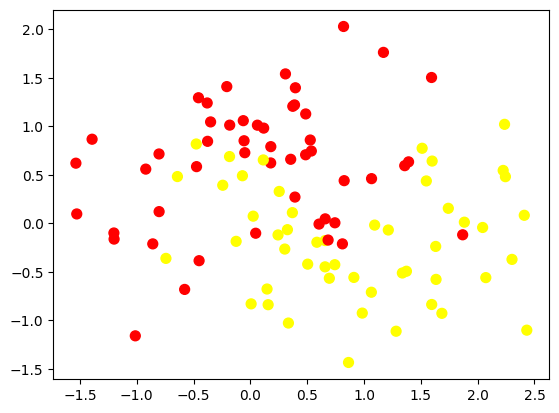

In [42]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')
plt.show()

## Model Builing with 0.5 Weight Initialization

---

### Model with Relu and Sigmoid Activation Functions

In [43]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(4, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [44]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.get_weights()

[array([[-0.51131344,  0.47954917, -0.06734872, -0.8417587 ],
        [ 0.95068526,  0.16380525, -0.49292588,  0.0649755 ]],
       dtype=float32),
 array([0., 0., 0., 0.], dtype=float32),
 array([[ 0.72815025],
        [-0.5685403 ],
        [-0.02358401],
        [ 0.2797048 ]], dtype=float32),
 array([0.], dtype=float32)]

In [46]:
len(model.get_weights())

4

In [47]:
initial_weights = model.get_weights()
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [48]:
model.set_weights(initial_weights)

In [49]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [50]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [51]:
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.4766 - loss: 1.3663 - val_accuracy: 0.5000 - val_loss: 1.0478
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4570 - loss: 1.3899 - val_accuracy: 0.5000 - val_loss: 1.0410
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5039 - loss: 1.3207 - val_accuracy: 0.5000 - val_loss: 1.0344
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4648 - loss: 1.3472 - val_accuracy: 0.5000 - val_loss: 1.0278
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5195 - loss: 1.2386 - val_accuracy: 0.5000 - val_loss: 1.0213
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5078 - loss: 1.2715 - val_accuracy: 0.5000 - val_loss: 1.0148
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4766 - loss: 1.2957 - val_accuracy: 0.5000 - val_loss: 1.0083
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5117 - loss: 1.2170 - val_accuracy: 0.5000 - val_loss

In [52]:
model.get_weights()

[array([[0.3542775 , 0.3542775 , 0.3542775 , 0.3542775 ],
        [0.25409624, 0.25409624, 0.25409624, 0.25409624]], dtype=float32),
 array([0.2827417, 0.2827417, 0.2827417, 0.2827417], dtype=float32),
 array([[0.2751155],
        [0.2751155],
        [0.2751155],
        [0.2751155]], dtype=float32),
 array([0.24778193], dtype=float32)]

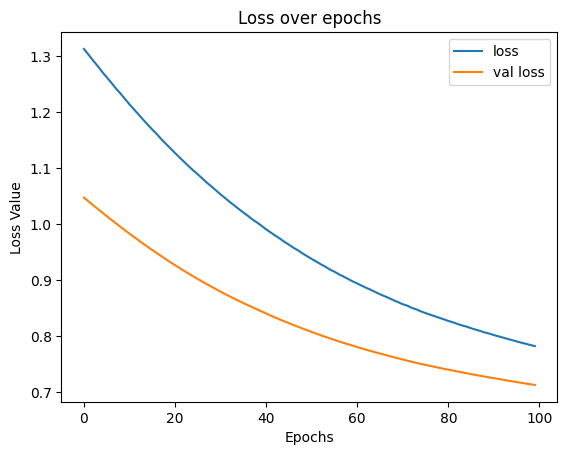

In [53]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.show()

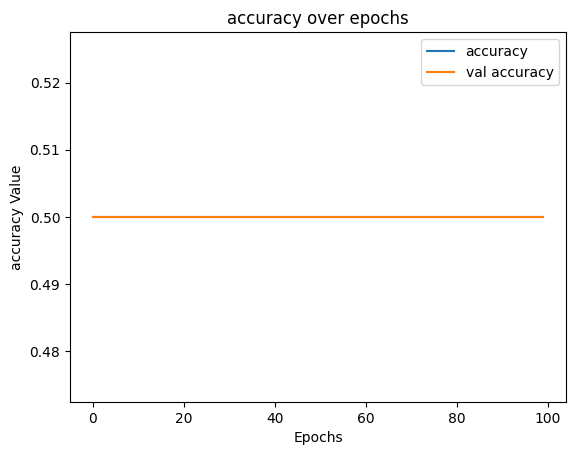

In [54]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("accuracy Value")
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


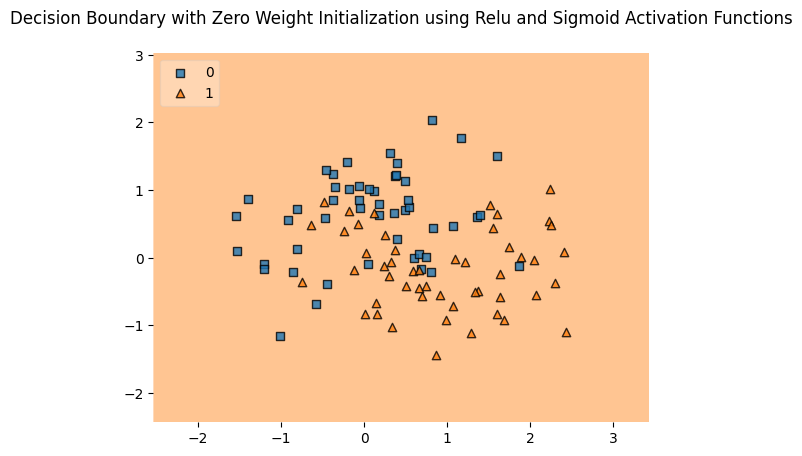

In [55]:
plot_decision_regions(X, y, clf=model, legend=2)
plt.title("Decision Boundary with Zero Weight Initialization using Relu and Sigmoid Activation Functions\n")
plt.show()

### Model with Tanh and Sigmoid Activation Function

In [56]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(4, activation='tanh'),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [57]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.get_weights()

[array([[ 0.5521319 ,  0.53003716, -0.39481854, -0.58674645],
        [ 0.8202205 , -0.05386662,  0.8845873 ,  0.8305416 ]],
       dtype=float32),
 array([0., 0., 0., 0.], dtype=float32),
 array([[-6.0720116e-01],
        [-4.6432018e-04],
        [-1.0419971e+00],
        [ 6.7526925e-01]], dtype=float32),
 array([0.], dtype=float32)]

In [59]:
model.set_weights(initial_weights)

In [60]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [61]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [62]:
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5000 - loss: 1.0381 - val_accuracy: 0.5500 - val_loss: 0.8863
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4688 - loss: 1.1013 - val_accuracy: 0.5500 - val_loss: 0.8813
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5156 - loss: 1.0336 - val_accuracy: 0.5500 - val_loss: 0.8763
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4648 - loss: 1.1101 - val_accuracy: 0.5500 - val_loss: 0.8713
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5273 - loss: 1.0138 - val_accuracy: 0.5500 - val_loss: 0.8665
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4844 - loss: 1.0783 - val_accuracy: 0.5500 - val_loss: 0.8617
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4570 - loss: 1.0915 - val_accuracy: 0.6000 - val_loss: 0.8571
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5391 - loss: 0.9716 - val_accuracy: 0.6000 - val_loss

In [63]:
model.get_weights()

[array([[0.64116323, 0.64116323, 0.64116323, 0.64116323],
        [0.22821938, 0.22821938, 0.22821938, 0.22821938]], dtype=float32),
 array([0.26389807, 0.26389807, 0.26389807, 0.26389807], dtype=float32),
 array([[0.27015248],
        [0.27015248],
        [0.27015248],
        [0.27015248]], dtype=float32),
 array([0.24790516], dtype=float32)]

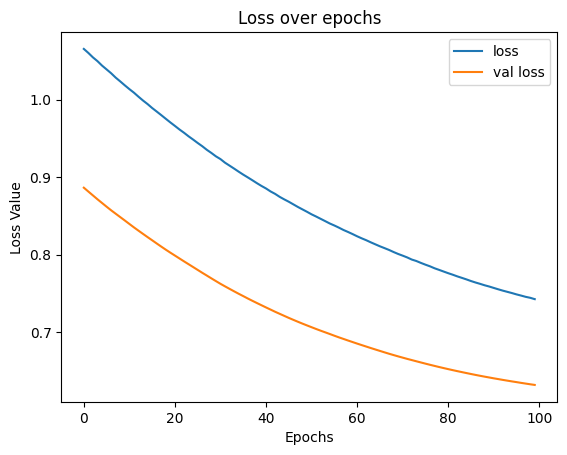

In [64]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.show()

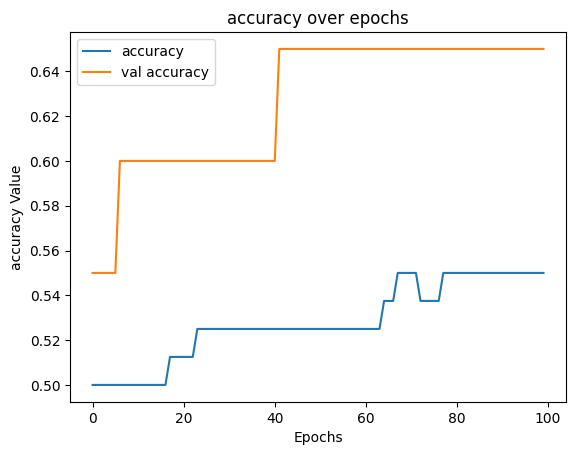

In [65]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("accuracy Value")
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 978us/step


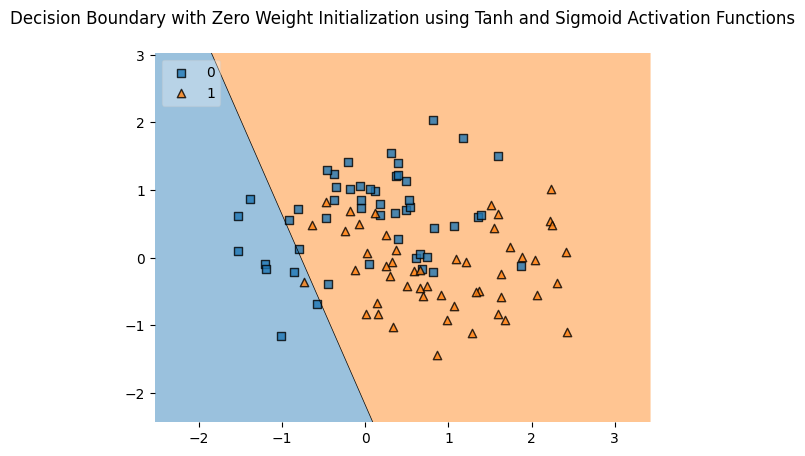

In [66]:
plot_decision_regions(X, y, clf=model, legend=2)
plt.title("Decision Boundary with Zero Weight Initialization using Tanh and Sigmoid Activation Functions\n")
plt.show()

### Model with Sigmoid Activation Functions at all layers

In [67]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(4, activation='sigmoid'),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [68]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [69]:
model.get_weights()

[array([[-0.23383784, -0.38294315,  0.3290875 ,  0.185112  ],
        [ 0.27463937, -0.18250489, -0.82292604,  0.5861645 ]],
       dtype=float32),
 array([0., 0., 0., 0.], dtype=float32),
 array([[ 0.14389253],
        [-0.16521686],
        [-0.25895685],
        [ 0.76808906]], dtype=float32),
 array([0.], dtype=float32)]

In [70]:
model.set_weights(initial_weights)

In [71]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [72]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [73]:
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.5117 - loss: 1.0782 - val_accuracy: 0.5000 - val_loss: 1.0230
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4688 - loss: 1.1377 - val_accuracy: 0.5000 - val_loss: 1.0186
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5039 - loss: 1.0854 - val_accuracy: 0.5000 - val_loss: 1.0142
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4961 - loss: 1.0856 - val_accuracy: 0.5000 - val_loss: 1.0098
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5312 - loss: 1.0114 - val_accuracy: 0.5000 - val_loss: 1.0055
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5273 - loss: 1.0267 - val_accuracy: 0.5000 - val_loss: 1.0012
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4766 - loss: 1.1088 - val_accuracy: 0.5000 - val_loss: 0.9969
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5273 - loss: 1.0083 - val_accuracy: 0.5000 - val_loss

In [74]:
model.get_weights()

[array([[0.5849148 , 0.5849148 , 0.5849148 , 0.5849148 ],
        [0.24763677, 0.24763677, 0.24763677, 0.24763677]], dtype=float32),
 array([0.2708152, 0.2708152, 0.2708152, 0.2708152], dtype=float32),
 array([[0.25134814],
        [0.25134814],
        [0.25134814],
        [0.25134814]], dtype=float32),
 array([0.242384], dtype=float32)]

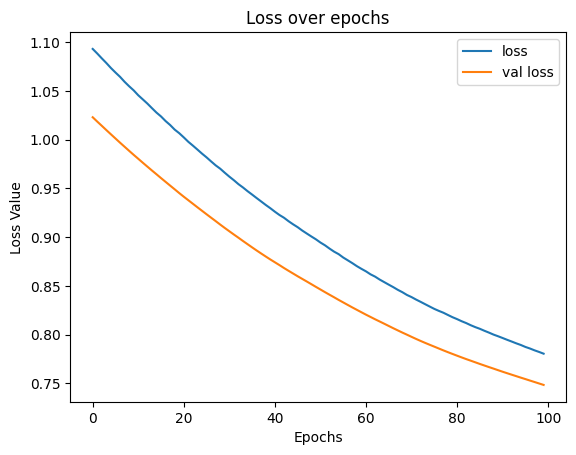

In [75]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.show()

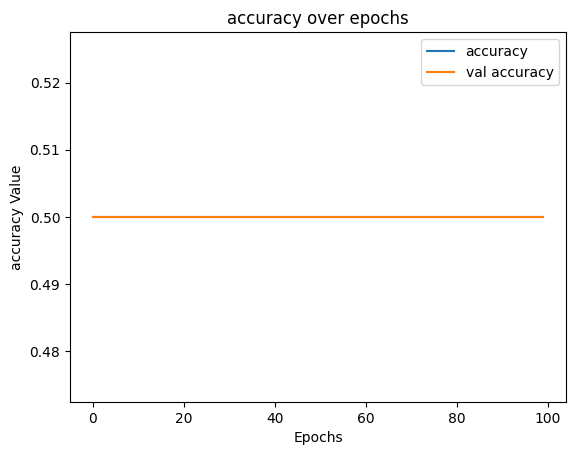

In [76]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("accuracy Value")
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


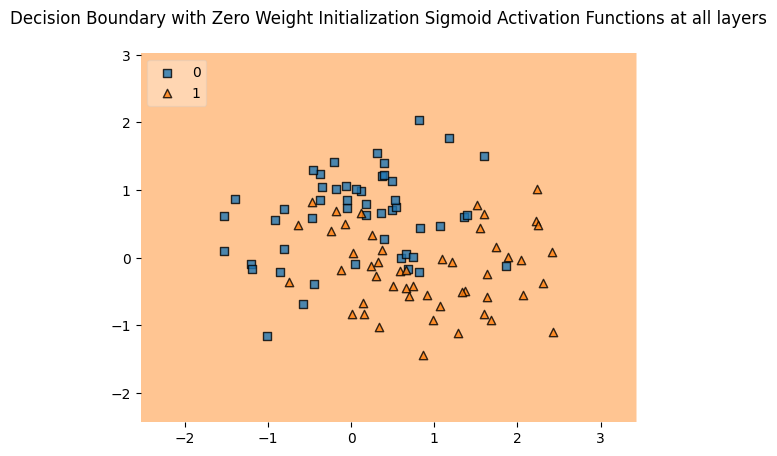

In [77]:
plot_decision_regions(X, y, clf=model, legend=2)
plt.title("Decision Boundary with Zero Weight Initialization Sigmoid Activation Functions at all layers\n")
plt.show()